In [ ]:
import squidpy as sq
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import stan
import anndata as ad


In [9]:
adata=sc.read_h5ad("data/Wu2021/scRNA.h5ad")
adata=adata[adata.obs['orig.ident']=="CID4535"]
sc.pp.filter_cells(adata, min_counts=100)
adata.layers['raw'] = adata.X
adata

Trying to set attribute `.obs` of view, copying.


AnnData object with n_obs × n_vars = 3961 × 29733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_counts'
    layers: 'raw'

In [10]:
adata=stan.pp.tf_gene(adata,
                      min_cells_proportion = 0.1,
                      min_tfs_per_gene= 5,
                      min_genes_per_tf= 10,
                      max_proportion_genes_per_tf= 0.8,
                      tf_gene_source="hTFtarget",
                      tf_list="humantfs",
                      inplace = False,
                      source_dir="data/tf_gene/")
sc.pp.normalize_total(adata)
adata.layers['scaled'] = np.sqrt(adata.to_df())
stan.pp.assign_folds(adata, n_folds=10)
print(adata)

/Users/aprilsagan/OneDrive - University of Pittsburgh/code/stan/stan/pp/tf_gene.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tf_gene['values']=1
/Users/aprilsagan/OneDrive - University of Pittsburgh/code/stan/stan/pp/tf_gene.py:155: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  tf_gene.drop(tf_gene.index[gene_sum<min_tfs_per_gene], 0,inplace=True)
/Users/aprilsagan/OneDrive - University of Pittsburgh/code/stan/stan/pp/tf_gene.py:156: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  tf_gene.drop(tf_gene.columns[tf_sum<min_genes_per_tf], 1,inplace=True)


AnnData object with n_obs × n_vars = 3961 × 7162
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'n_counts'
    var: 'n_cells', 'fold'
    uns: 'tf_names'
    varm: 'tf_gene'
    layers: 'raw', 'scaled'


In [11]:
stl_model=stan.models.SpaTraFact_stl(adata, layer='scaled', intercept=False)
stl_model.fit(n_steps=5,
              stages=1,
              grid_search_params={'lambda1':[1e-6, 1e6]},
              axis=0,
              verbose=False)
print(stl_model.evaluate(fold=-1, return_string=True))
adata.obs['pred_cor_stl']=stl_model.evaluate(fold=-1)[0]
adata.var['pred_cor_stl']=stl_model.evaluate(fold=-1)[1]
adata.obsm['stl_tfa']=pd.DataFrame(stl_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

Sample Cor:0.262 Gene Cor: 0.175


In [24]:
tfa.groupby(adata.obs['celltype_major']).mean().T

celltype_major,B-cells,CAFs,Cancer Epithelial,Endothelial,Myeloid,Normal Epithelial,PVL,Plasmablasts,T-cells
AHR,-0.069732,-0.637658,0.181894,-0.515036,-0.314193,0.035166,-0.233909,0.005908,-0.013535
AR,0.373330,-0.602030,0.286971,-0.125341,-0.433284,0.452059,-0.924554,0.103993,0.171486
ARID3A,-0.771437,-0.523095,0.195995,0.550047,-0.184898,0.033957,-0.337489,-0.483968,-0.421577
ARNT,-0.950680,-0.517958,0.512124,-0.679219,-1.158295,0.314498,-0.454416,0.032910,-0.831646
ARNTL,-0.094489,-0.589093,0.180179,-0.245127,-0.427127,-0.653945,-0.120792,-0.382739,-0.126064
...,...,...,...,...,...,...,...,...,...
ZNF250,-0.303506,-0.540255,0.580536,-1.381847,-1.029088,0.359297,-0.894747,-0.294529,-0.260924
ZNF263,-0.727550,0.044360,0.116208,-0.238617,-0.639931,-1.020374,0.503636,-0.111311,-0.686088
ZNF281,-1.123534,-0.037265,0.110958,0.252924,-0.718112,0.206992,0.577953,-0.457589,-0.896427
ZNF384,0.016793,-0.477802,0.099959,0.053525,0.416842,-0.085353,-0.431511,-0.276554,-0.021585


         Falling back to preprocessing with `sc.pp.pca` and default params.


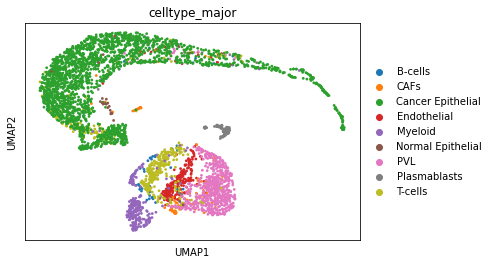

In [13]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color="celltype_major")

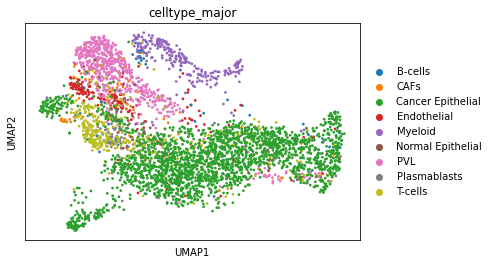

In [14]:
sc.pp.neighbors(adata, use_rep="stl_tfa")
sc.tl.umap(adata)
sc.pl.umap(adata, color="celltype_major")

In [16]:
adata.write("out/CID4535_tfa.h5ad")

In [23]:
import anndata as ad
adata_tfa=ad.AnnData(X=adata.obsm["stl_tfa"], obs=adata.obs)
adata_tfa.var_names=adata.uns['tf_names']
adata_tfa.write("out/CID4535_tfa_only.h5ad")

In [ ]:
adata=sc.read_h5ad("data/Wu2021/scRNA.h5ad")
for sample in ["CID4290A", "CID4465", "CID4535", "CID44971"]:
    print("-"*20, sample, "-"*20)
    adata=sc.read_h5ad("data/Wu2021/scRNA.h5ad")

    adata=adata[adata.obs['orig.ident']==sample]
    sc.pp.filter_cells(adata, min_counts=100)
    adata.layers['raw'] = adata.X

    adata=stan.pp.tf_gene(adata,
                          min_cells_proportion = 0.05,
                          min_tfs_per_gene= 5,
                          min_genes_per_tf= 10,
                          max_proportion_genes_per_tf= 0.8,
                          tf_gene_source="hTFtarget",
                          tf_list="humantfs",
                          inplace = False,
                          source_dir="data/tf_gene/")
    print(adata)
    sc.pp.normalize_total(adata)
    adata.layers['scaled'] = np.sqrt(adata.to_df())
    stan.pp.assign_folds(adata, n_folds=10)

    stl_model=stan.models.SpaTraFact_stl(adata, layer='scaled', intercept=False)
    stl_model.fit(n_steps=5,
                  stages=1,
                  grid_search_params={'lambda1':[1e-6, 1e6]},
                  axis=0,
                  verbose=False)
    print(stl_model.evaluate(fold=-1, return_string=True))
    adata.obs['pred_cor']=stl_model.evaluate(fold=-1)[0]
    adata.var['pred_cor']=stl_model.evaluate(fold=-1)[1]
    adata.obsm['tfa']=pd.DataFrame(stl_model.W_concat.T, index=adata.obs_names, columns=adata.uns['tf_names'])

    adata.write("out/"+sample+"_sc.h5ad")

    adata_tfa=ad.AnnData(X=adata.obsm["tfa"], obs=adata.obs)
    adata_tfa.var_names=adata.uns['tf_names']
    adata_tfa.write("out/"+sample+"_sc_tfa_only.h5ad")